In [36]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import mlflow
import mlflow.sklearn

In [37]:
df = pd.read_csv("../SOURCE/dataset.csv")
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

In [39]:
df = df.drop(columns=['customer_id']) # Supprimer l'ID (non prédictif) [cite: 109]

In [40]:
df['complaint_type'] = df['complaint_type'].fillna('None')

# 2. Définition des colonnes
target = 'churn'
X = df.drop(columns=[target])
y = df[target]

# Identifier les types de colonnes automatiquement
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Création des transformateurs [cite: 330]
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Indispensable pour le Deep Learning (MLP) [cite: 259, 317]
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Encode les variables texte 
])

# Combiner les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 4. Découpage Train/Test rigoureux [cite: 273, 329]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y # Stratify pour gérer le déséquilibre [cite: 308]
)

print(f"Taille du train set : {X_train.shape}")
print(f"Taille du test set : {X_test.shape}")

Taille du train set : (8000, 30)
Taille du test set : (2000, 30)


In [41]:
# 1. Définition des 4 modèles
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Deep Learning (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 2. Entraînement et Évaluation
results = {}

In [42]:
for name, model in models.items():
    # Création d'un pipeline complet pour chaque modèle
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor), # On réutilise le preprocessor d'avant
        ('classifier', model)
    ])
    
    # Entraînement
    pipeline.fit(X_train, y_train)
    
    # Prédictions
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Stockage des scores
    results[name] = {
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Report": classification_report(y_test, y_pred, output_dict=True)
    }
    
    print(f"--- {name} ---")
    print(f"ROC-AUC Score: {results[name]['ROC_AUC']:.4f}")
    print(f"Recall (Class 1): {results[name]['Report']['1']['recall']:.4f}\n")

--- Logistic Regression (Baseline) ---
ROC-AUC Score: 0.7245
Recall (Class 1): 0.6569

--- Random Forest ---
ROC-AUC Score: 0.7956
Recall (Class 1): 0.0049

--- Gradient Boosting ---
ROC-AUC Score: 0.8064
Recall (Class 1): 0.0931

--- Deep Learning (MLP) ---
ROC-AUC Score: 0.6512
Recall (Class 1): 0.2010



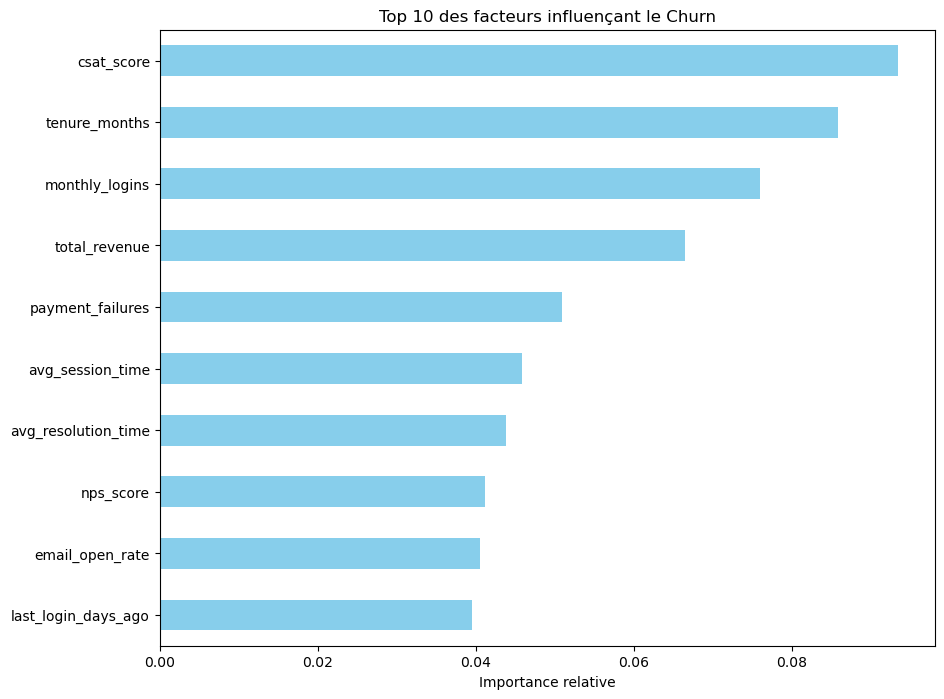

In [43]:
rf_model = models["Random Forest"]
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', rf_model)])
pipeline_rf.fit(X_train, y_train)

# Récupérer les noms des colonnes après transformation OneHot
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_features_transformed = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + cat_features_transformed

# Extraire l'importance
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=all_features).sort_values(ascending=True)

# Affichage
plt.figure(figsize=(10,8))
feat_importances.tail(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 des facteurs influençant le Churn")
plt.xlabel("Importance relative")
plt.show()

In [52]:
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score
from mlflow.models import infer_signature

# Initialisation des modèles (Exigence: min 4 modèles dont 1 DL) [cite: 319, 320]
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Deep Learning (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 1. Configuration de l'expérience MLflow [cite: 418]
mlflow.set_experiment("Churn_Prediction_Project")

# Chargement du dataset (remplace par le bon nom de fichier)
df = pd.read_csv('../SOURCE/dataset.csv') 

# Nettoyage des données [cite: 460]
df['complaint_type'] = df['complaint_type'].fillna('None') 

target = 'churn'
X = df.drop(columns=[target, 'customer_id']) # Retrait de l'ID client [cite: 452]
y = df[target]

# Pipeline de préparation (Scaling + Encoding) [cite: 259, 317, 460]
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Découpage Train/Test avec stratification pour le déséquilibre [cite: 273, 308, 329]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y 
)

# 2. Boucle d'entraînement et tracking MLflow [cite: 461, 462]
for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Création du pipeline complet pour éviter le data leakage [cite: 330]
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])
        
        # Entraînement [cite: 130]
        pipeline.fit(X_train, y_train)
        
        # Prédictions
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Calcul des métriques [cite: 470]
        roc_auc = roc_auc_score(y_test, y_proba)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Signature pour l'API [cite: 136]
        signature = infer_signature(X_test, y_pred)
        
        # Logging MLflow [cite: 101, 103]
        mlflow.log_param("model_type", name)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        
        # Enregistrement du modèle (Artifact)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            artifact_path="model",
            signature=signature,
            input_example=X_test.iloc[:5]
        )
        
        # Enregistrement dans le Model Registry [cite: 432, 434]
        mlflow.register_model(model_info.model_uri, "Churn_Classifier")

        print(f"--- {name} ---")
        print(f"ROC-AUC: {roc_auc:.4f} | Recall: {recall:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/23 15:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'Churn_Classifier' already exists. Creating a new version of this model...
Created version '5' of model 'Churn_Classifie

--- Logistic Regression (Baseline) ---
ROC-AUC: 0.7245 | Recall: 0.6569


/opt/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/23 15:26:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'Churn_Classifier' already exists. Creating a new version of this model...
Created version '6' of model 'Churn_Classifie

--- Random Forest ---
ROC-AUC: 0.7956 | Recall: 0.0049


/opt/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/23 15:26:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'Churn_Classifier' already exists. Creating a new version of this model...
Created version '7' of model 'Churn_Classifie

--- Gradient Boosting ---
ROC-AUC: 0.8064 | Recall: 0.0931


/opt/anaconda3/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/23 15:26:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


--- Deep Learning (MLP) ---
ROC-AUC: 0.6512 | Recall: 0.2010


Registered model 'Churn_Classifier' already exists. Creating a new version of this model...
Created version '8' of model 'Churn_Classifier'.
